<a href="https://colab.research.google.com/github/Ayush374/EDA/blob/main/21BDS0390.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EDA**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
data_path = '/content/wages.csv'
df = pd.read_csv(data_path)

Display First Few rows

In [3]:
display(df.head())

,rownames,id,lnw,exper,ged,postexp,black,hispanic,hgc,hgc.9,uerate,ue.7,ue.centert1,ue.mean,ue.person.cen,ue1
0,1,31,1.491,0.015,1,0.015,0,1,8,-1,3.21,-3.785,0.00,3.21,0.00,3.21
1,2,31,1.433,0.715,1,0.715,0,1,8,-1,3.21,-3.785,0.00,3.21,0.00,3.21
2,3,31,1.469,1.734,1,1.734,0,1,8,-1,3.21,-3.785,0.00,3.21,0.00,3.21
3,4,31,1.749,2.773,1,2.773,0,1,8,-1,3.30,-3.705,0.08,3.21,0.08,3.21
4,5,31,1.931,3.927,1,3.927,0,1,8,-1,2.89,-4.105,-0.32,3.21,-0.32,3.21


Dimension Analysis

In [4]:
print("Dataset Dimensions:", df.shape)

Dataset Dimensions: (6402, 16)


 Summary Statistics

In [5]:

print("\nSummary Statistics:\n", df.describe(include='all'))


Summary Statistics:
           rownames            id          lnw        exper          ged  \
count  6402.000000   6402.000000  6402.000000  6402.000000  6402.000000   
mean   3201.500000   6300.923930     1.896686     3.957221     0.271946   
std    1848.242544   3548.319594     0.427669     2.797018     0.444997   
min       1.000000     31.000000     0.708000     0.001000     0.000000   
25%    1601.250000   3194.000000     1.591000     1.609000     0.000000   
50%    3201.500000   6582.000000     1.842000     3.451000     0.000000   
75%    4801.750000   9300.000000     2.140000     5.949500     1.000000   
max    6402.000000  12543.000000     4.304000    12.700000     1.000000   

           postexp        black     hispanic          hgc        hgc.9  \
count  6402.000000  6402.000000  6402.000000  6402.000000  6402.000000   
mean      0.907643     0.252890     0.241018     8.947516    -0.052484   
std       2.000627     0.434702     0.427735     1.347135     1.347135   
min   

Data Handling

In [6]:
# Checking Data Types and Missing Values
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# Data Cleaning: Handling Missing Values
df = df.dropna()
print("\nAfter Dropping Missing Values, New Dimensions:", df.shape)


Data Types:
 rownames           int64
id                 int64
lnw              float64
exper            float64
ged                int64
postexp          float64
black              int64
hispanic           int64
hgc                int64
hgc.9              int64
uerate           float64
ue.7             float64
ue.centert1      float64
ue.mean          float64
ue.person.cen    float64
ue1              float64
dtype: object

Missing Values:
 rownames           0
id                 0
lnw                0
exper              0
ged                0
postexp            0
black              0
hispanic           0
hgc                0
hgc.9              0
uerate             0
ue.7             402
ue.centert1      406
ue.mean            0
ue.person.cen      0
ue1                0
dtype: int64

After Dropping Missing Values, New Dimensions: (5603, 16)


Univariate Analysis

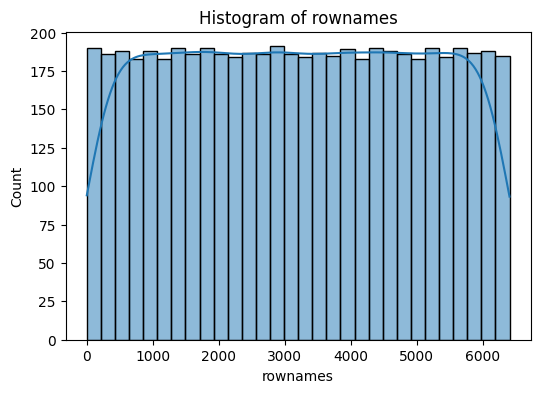

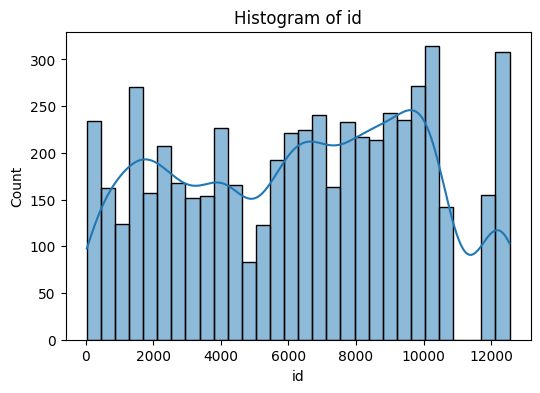

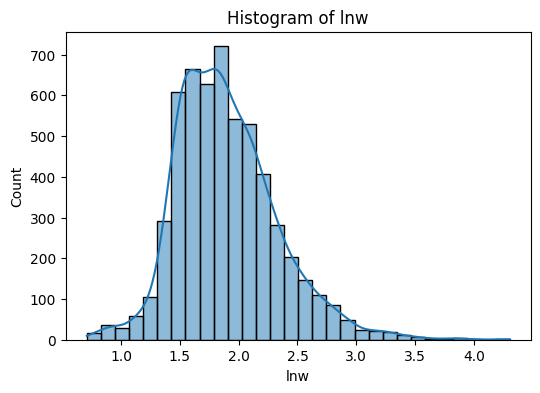

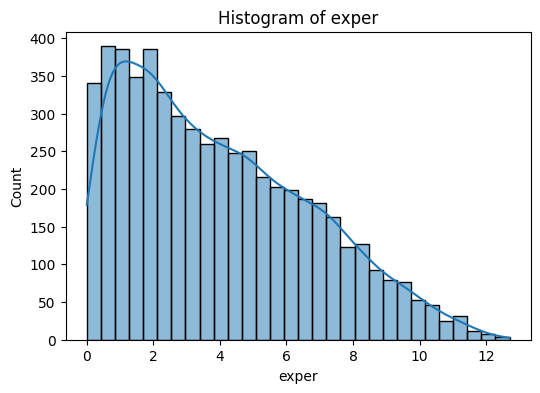

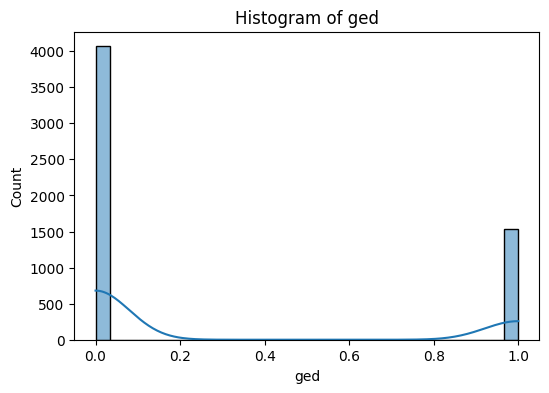

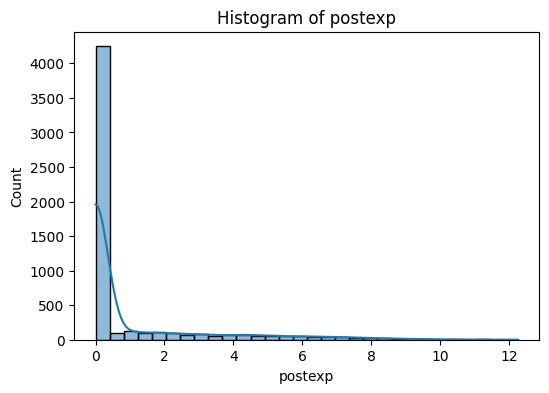

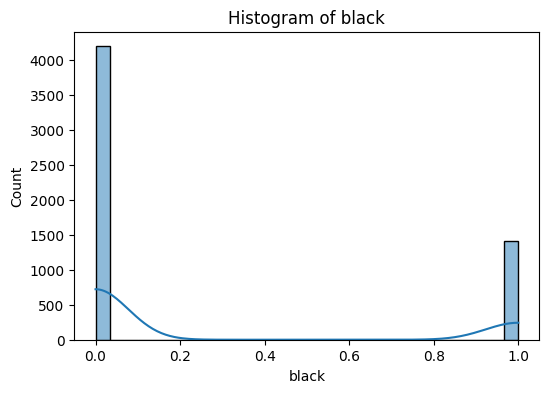

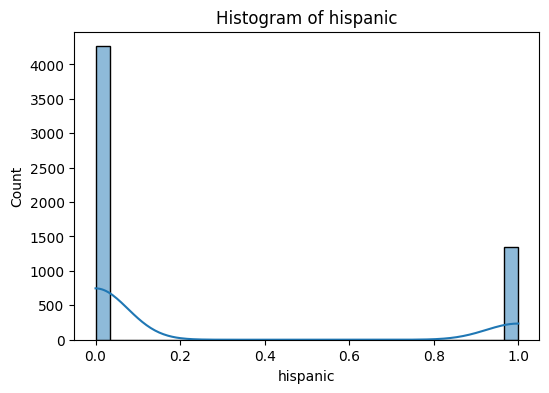

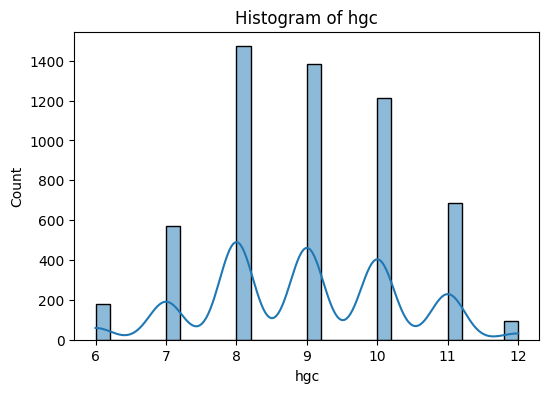

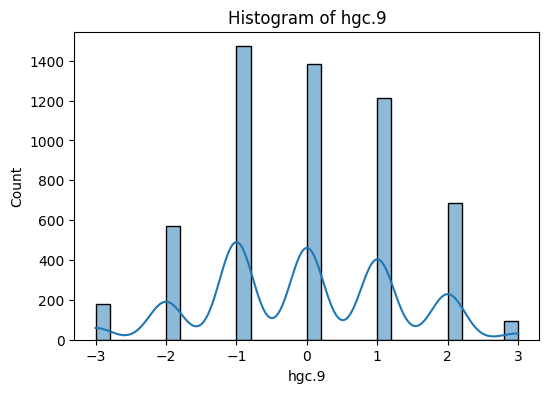

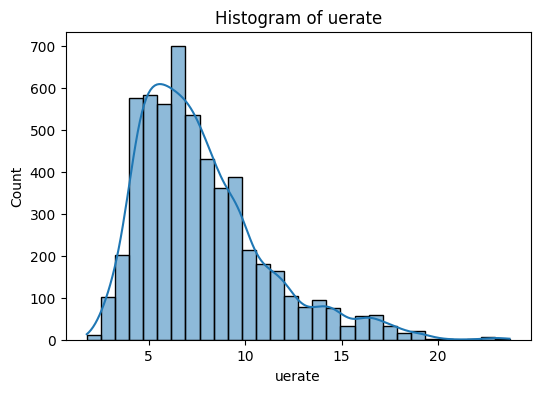

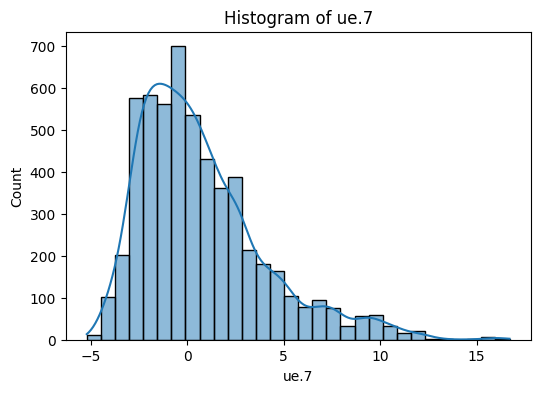

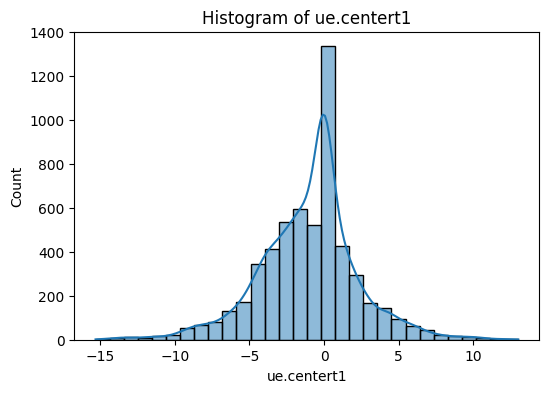

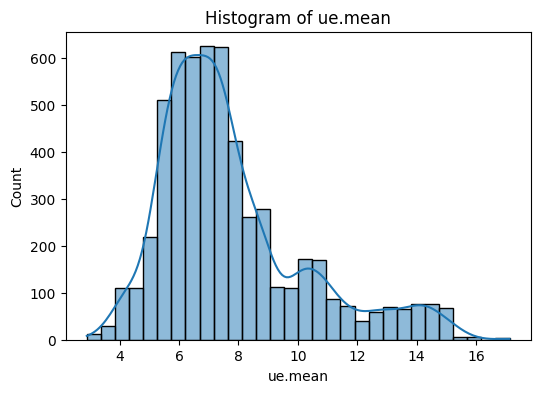

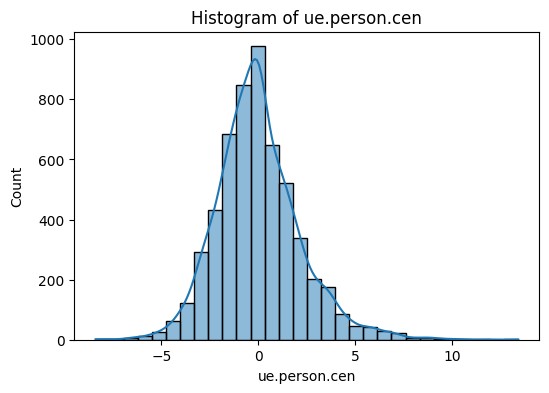

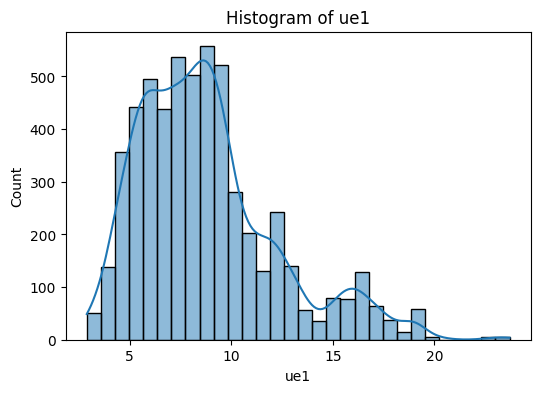

In [7]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Histogram of {col}')
    plt.show()


Boxplot visualisation

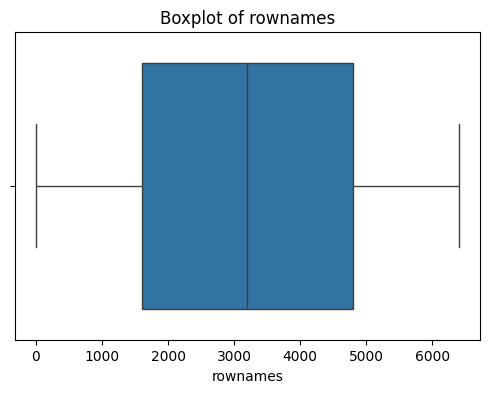

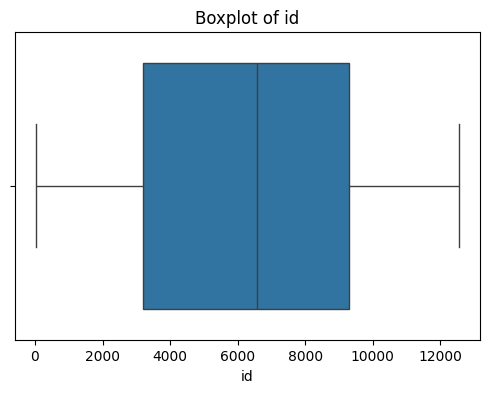

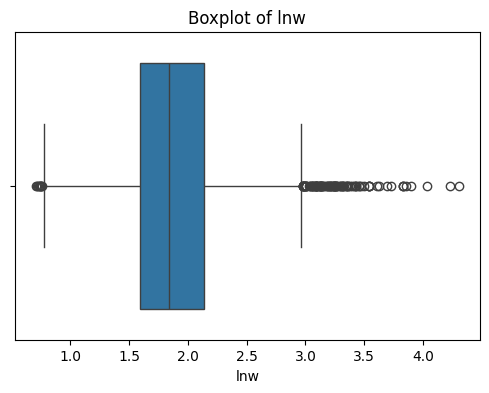

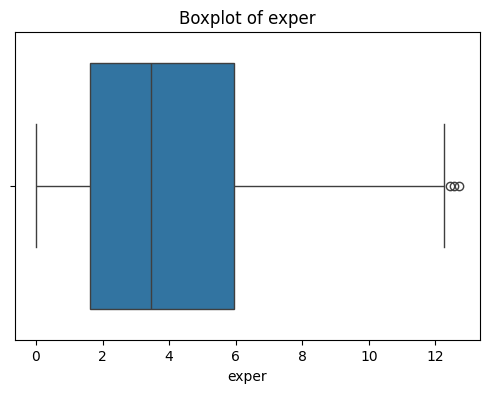

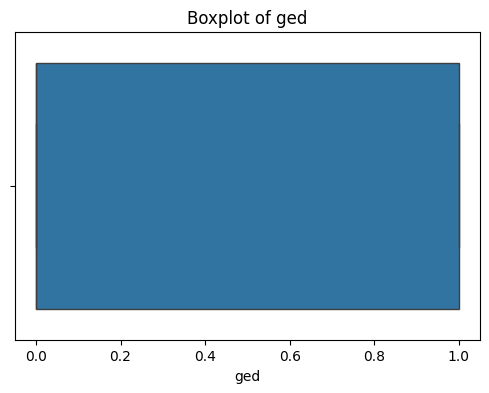

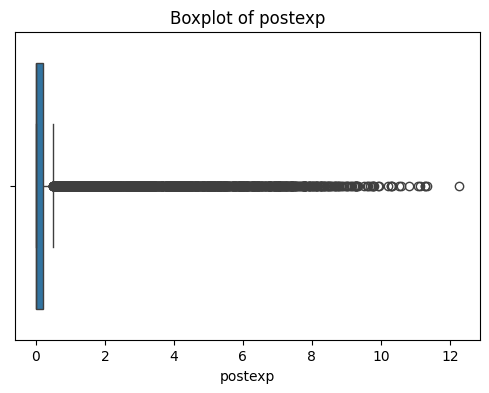

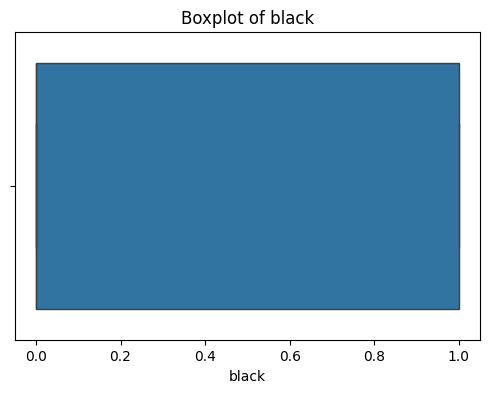

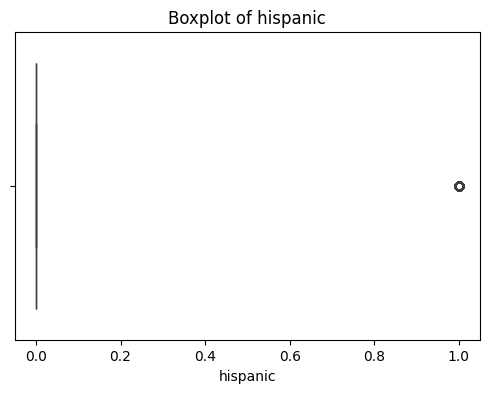

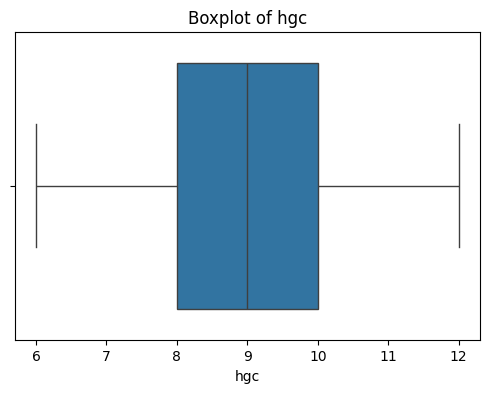

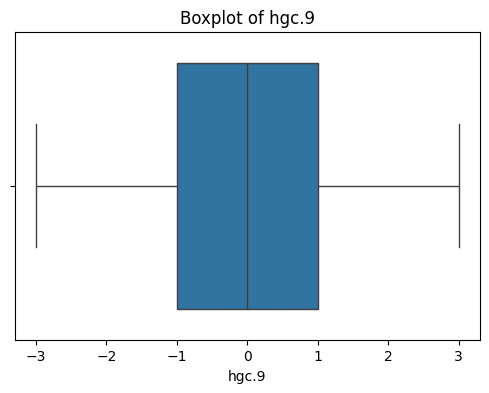

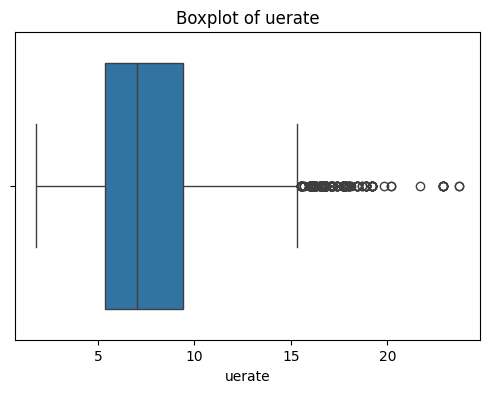

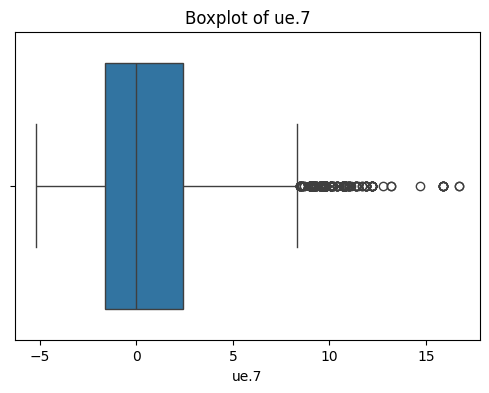

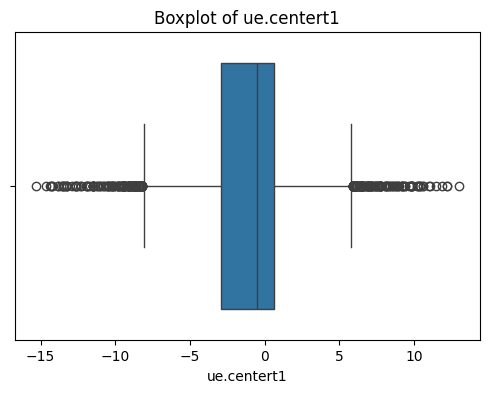

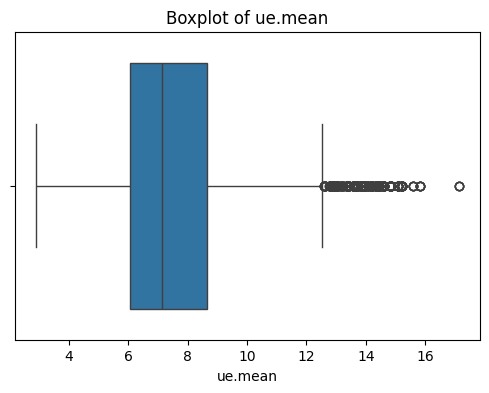

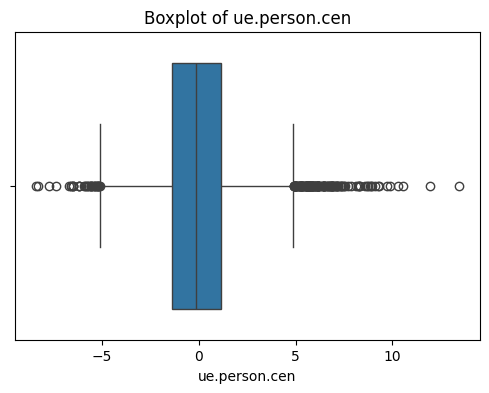

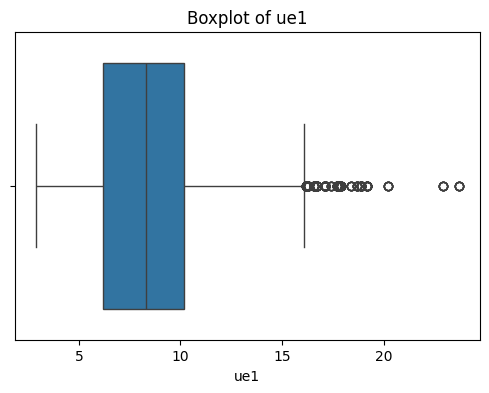

In [8]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Bivariate Analysis


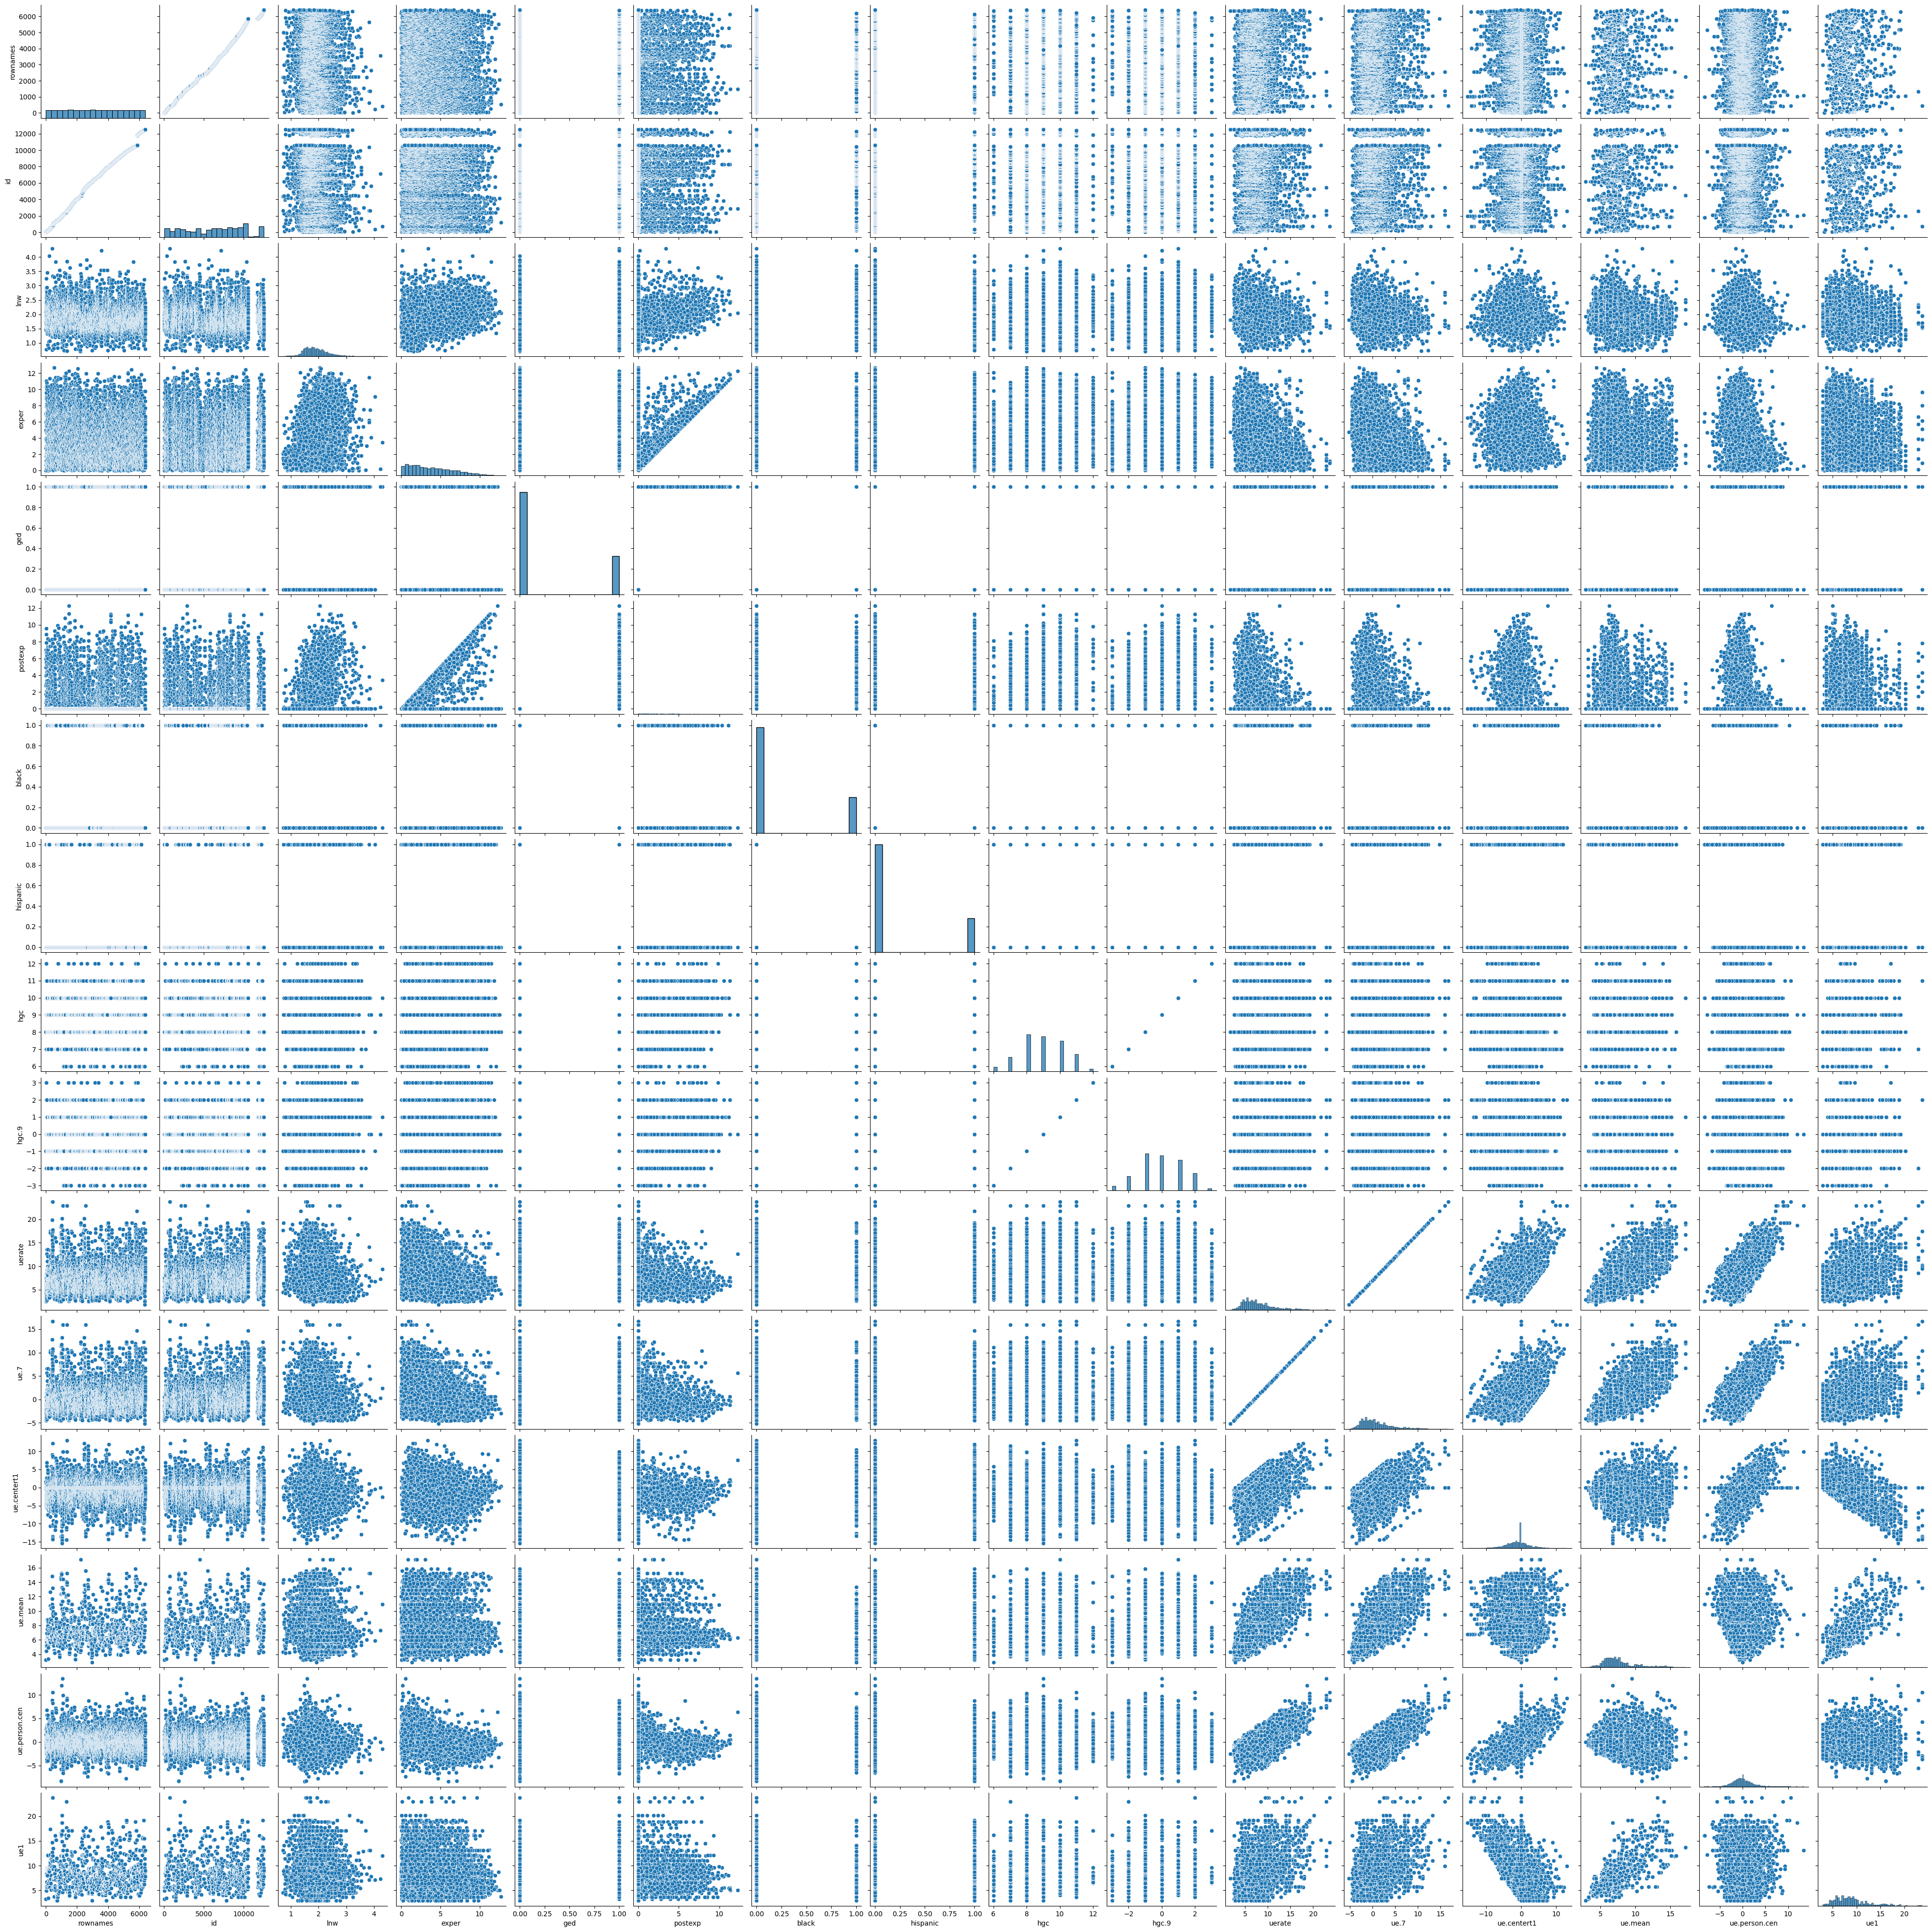

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if len(numeric_cols) >= 2:
    sns.pairplot(df[numeric_cols])
    plt.show()

Correlation Heatmap


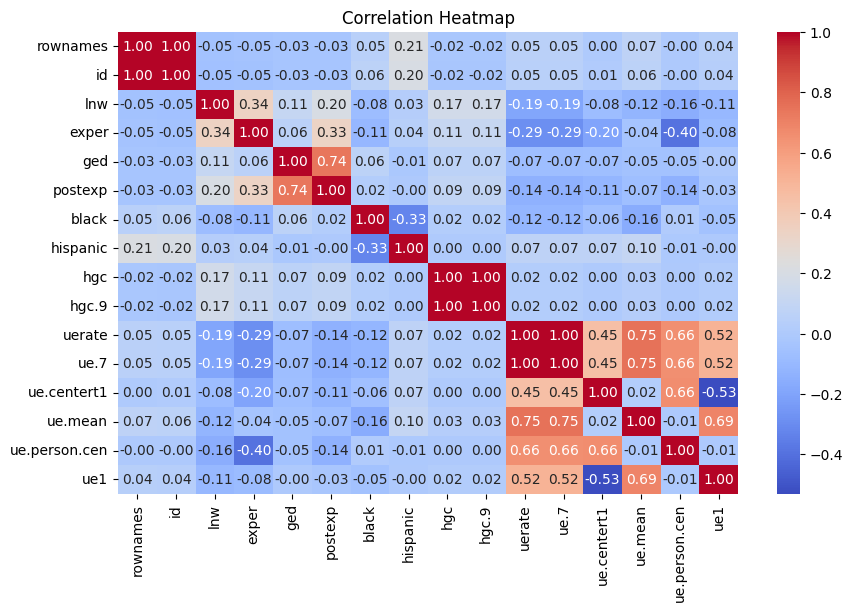

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Categorical Variables Visualization


In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col])
    plt.title(f'Countplot of {col}')
    plt.show()

print("Data analysis complete.")

Data analysis complete.


In [12]:
# Dimensionality Reduction using PCA
features_for_pca = df.select_dtypes(include=["number"]).drop(columns=["lnw"])  # Exclude target
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_pca)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

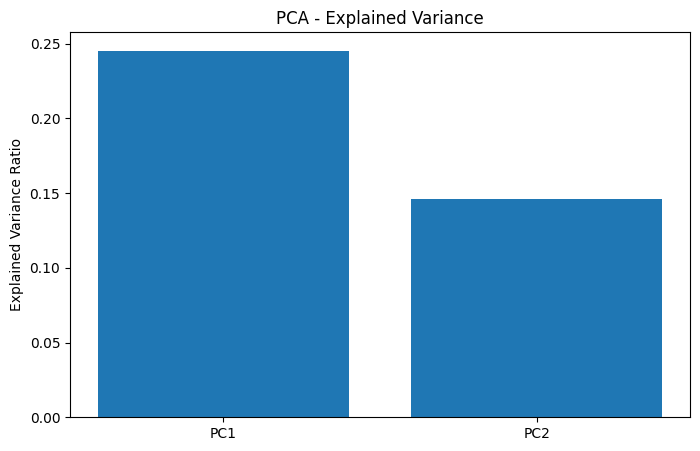

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, 3), pca.explained_variance_ratio_, tick_label=["PC1", "PC2"])
plt.ylabel("Explained Variance Ratio")
plt.title("PCA - Explained Variance")
plt.show()

In [14]:

# Model Building - Predicting Log Wages
X = df.drop(columns=["lnw"])  # Features
y = df["lnw"]  # Target variable

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-Squared Score: {r2:.4f}")

Mean Squared Error: 0.1716
R-Squared Score: 0.1331
